# Feature Engineering y Modelado
---

## Objetivo del notebook
En el notebook anterior exploramos los datos. Ahora vamos a:

1. **Seleccionar** las columnas más útiles.
2. **Manejar valores nulos**.
3. **Crear nuevas características** (feature engineering).
4. **Dividir** los datos en entrenamiento y prueba.
5. **Entrenar y comparar TRES estrategias** para manejar el desbalanceo de clases:
   - **XGBoost + SMOTE** (balanceo sintético)
   - **XGBoost + scale_pos_weight** (ponderación de clases, sin SMOTE)
   - **Random Forest + SMOTE** (balanceo sintético con otro modelo)
6. **Evaluar** con métricas adecuadas (Recall, Precisión, F2-score) y **comparar resultados**.

Al final, sabremos qué enfoque funciona mejor para este dataset de fraude.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# Modelo XGBoost
from xgboost import XGBClassifier

# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas")

✅ Librerías importadas


## 1. Cargar los datos combinados
---
Cargamos los archivos CSV de transacciones e identidad, luego los fusionamos por `TransactionID`. Usamos `how='left'` para conservar todas las transacciones.

In [3]:
import pandas as pd
import numpy as np

# ==================================================
# Definición de columnas a cargar (para ahorrar memoria)
# ==================================================
columnas_numericas = ['TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card3', 'addr1', 'addr2', 'dist1', 'dist2']
columnas_c = [f'C{i}' for i in range(1, 15)]
columnas_d = [f'D{i}' for i in range(1, 16)]
columnas_id = [f'id_{i:02d}' for i in range(1, 39)]
columnas_categoricas = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']  # Estas están en transacciones

# Columnas para cada archivo
cols_trans = ['TransactionID', 'isFraud'] + columnas_numericas + columnas_c + columnas_d + columnas_categoricas
cols_id = ['TransactionID'] + columnas_id + ['DeviceType', 'DeviceInfo']  # Solo las que existen en identity

# ==================================================
# Carga de archivos CSV con las columnas seleccionadas
# ==================================================
print("Cargando train_transaction.csv (solo columnas útiles)...")
df_trans = pd.read_csv('../data/raw/train_transaction.csv', usecols=cols_trans)
print(f"Shape transacciones: {df_trans.shape}")

print("Cargando train_identity.csv (solo columnas útiles)...")
df_id = pd.read_csv('../data/raw/train_identity.csv', usecols=cols_id)
print(f"Shape identidades: {df_id.shape}")

# ==================================================
# Unión (left join)
# ==================================================
print("Uniendo tablas...")
df = pd.merge(df_trans, df_id, on='TransactionID', how='left')
print(f"Dataset combinado shape: {df.shape[0]} filas, {df.shape[1]} columnas")

# ==================================================
# USAR SUBCONJUNTO PARA DESARROLLO (10% del dataset)
# ==================================================
print("Usando 10% del dataset para desarrollo...")
df = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"Subconjunto: {df.shape[0]} filas, {df.shape[1]} columnas")

# Liberar memoria de los dataframes originales
del df_trans, df_id

Cargando train_transaction.csv (solo columnas útiles)...


Shape transacciones: (590540, 45)
Cargando train_identity.csv (solo columnas útiles)...
Shape identidades: (144233, 41)
Uniendo tablas...
Dataset combinado shape: 590540 filas, 85 columnas
Usando 10% del dataset para desarrollo...
Subconjunto: 59054 filas, 85 columnas


## 2. Selección de columnas (reducir dimensionalidad)
---
Para simplificar y evitar overfitting, seleccionaremos un subconjunto de columnas que suelen ser importantes en detección de fraudes. Eliminamos columnas con >80% nulos después de la selección.

In [6]:
# Definir columnas que queremos conservar (basado en literatura de fraudes)
columnas_numericas = ['TransactionAmt', 'TransactionDT', 'card1', 'card2', 'card3', 'addr1', 'addr2', 'dist1', 'dist2']
columnas_c = [f'C{i}' for i in range(1, 15)]        # C1 a C14
columnas_d = [f'D{i}' for i in range(1, 16)]        # D1 a D15
columnas_id = [f'id_{i:02d}' for i in range(1, 39)] # id_01 a id_38
columnas_categoricas = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo']

cols_keep = ['TransactionID', 'isFraud'] + columnas_numericas + columnas_c + columnas_d + columnas_categoricas + columnas_id
cols_keep = [col for col in cols_keep if col in df.columns]

print(f"Seleccionadas {len(cols_keep)} columnas (incluyendo target)")
df_subset = df[cols_keep].copy()
print(f"Shape del subset: {df_subset.shape}")

Seleccionadas 85 columnas (incluyendo target)
Shape del subset: (59054, 85)


## 3. Manejo de valores nulos
---
Eliminamos columnas con más del 80% de nulos. Luego imputamos el resto: numéricas con la mediana, categóricas con 'Unknown'.

In [7]:
# Calcular porcentaje de nulos
null_perc = df_subset.isnull().mean() * 100
print("Porcentaje de nulos por columna (primeras 10):")
print(null_perc.sort_values(ascending=False).head(10))

# Eliminar columnas con >80% nulos
high_null_cols = null_perc[null_perc > 80].index.tolist()
df_subset.drop(columns=high_null_cols, inplace=True)
print(f"\nEliminadas {len(high_null_cols)} columnas con >80% nulos. Nuevo shape: {df_subset.shape}")

# Separar numéricas y categóricas
numeric_cols = df_subset.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['isFraud', 'TransactionID']]
categorical_cols = df_subset.select_dtypes(include=['object']).columns.tolist()

# Imputar TODOS los valores nulos restantes con -999 para numéricas y 'Unknown' para categóricas
df_subset[numeric_cols] = df_subset[numeric_cols].fillna(-999)
df_subset[categorical_cols] = df_subset[categorical_cols].fillna('Unknown')

# Verificación final de nulos
total_nulos = df_subset.isnull().sum().sum()
print(f"\nVerificación de nulos después de imputar: {total_nulos}")
if total_nulos > 0:
    print("Columnas con nulos restantes:")
    print(df_subset.isnull().sum()[df_subset.isnull().sum() > 0])
else:
    print("✅ No hay valores nulos restantes")

# ==================================================
# Recrear X e y después de imputación completa
# ==================================================
X = df_subset.drop(['TransactionID', 'isFraud'], axis=1)
y = df_subset['isFraud']

# División estratificada (mantiene proporción de fraude)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\n📊 Datos preparados:")
print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")
print(f"Proporción de fraude en train: {y_train.mean():.4%}")
print(f"Proporción de fraude en test: {y_test.mean():.4%}")

Porcentaje de nulos por columna (primeras 10):
id_24    99.231212
id_25    99.163477
id_08    99.160091
id_07    99.160091
id_21    99.158397
id_26    99.156704
id_23    99.156704
id_22    99.156704
id_27    99.156704
dist2    93.737935
dtype: float64

Eliminadas 28 columnas con >80% nulos. Nuevo shape: (59054, 57)

Verificación de nulos después de imputar: 0
✅ No hay valores nulos restantes

📊 Datos preparados:
Tamaño entrenamiento: (47243, 55)
Tamaño prueba: (11811, 55)
Proporción de fraude en train: 3.5709%
Proporción de fraude en test: 3.5729%


## 4. Feature Engineering: Crear nuevas variables
---
Vamos a agregar características derivadas que pueden ayudar al modelo:
- **Fracción del monto respecto a la media por tarjeta** (`card1`).
- **Día de la semana o hora** a partir de TransactionDT (aunque no es fecha real, podemos crear ciclos).
- **Interacciones** entre variables (ej. `TransactionAmt * card2`).
- **Probabilidades de fraude por producto** (target encoding) - lo dejaremos para más adelante.

Por ahora, crearemos una característica simple: `TransactionAmt_log` (logaritmo para estabilizar la varianza) y `hour_of_day` simulada (por si el tiempo es relevante).


In [9]:
# Log del monto (evita valores extremos)
df_subset['TransactionAmt_log'] = np.log1p(df_subset['TransactionAmt'])

# Simular hora del día: TransactionDT es una especie de timestamp, lo normalizamos a 0-23
max_dt = df_subset['TransactionDT'].max()
df_subset['hour_sim'] = (df_subset['TransactionDT'] / max_dt * 24).astype(int)

print("Nuevas características agregadas:")
print(df_subset[['TransactionAmt', 'TransactionAmt_log', 'hour_sim']].head())

Nuevas características agregadas:
   TransactionAmt  TransactionAmt_log  hour_sim
0         724.000            6.586172        18
1         108.500            4.695925        22
2          47.950            3.890799        10
3         100.599            4.621034         8
4         107.950            4.690889        10


## 5. Codificación de variables categóricas
---
Los modelos numéricos (XGBoost) no aceptan texto directamente. Convertimos las variables categóricas a números usando `LabelEncoder` (por simplicidad; para mejor rendimiento podríamos usar One-Hot Encoding, pero con muchas categorías puede ser pesado).

In [10]:
# Aplicar LabelEncoder a cada columna categórica
from sklearn.preprocessing import LabelEncoder
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_subset[col] = le.fit_transform(df_subset[col].astype(str))
    le_dict[col] = le
    print(f"Codificada {col} con {len(le.classes_)} categorías")

print("\nDataset completamente numérico. Shape final:", df_subset.shape)

Codificada ProductCD con 5 categorías
Codificada card4 con 5 categorías
Codificada card6 con 5 categorías
Codificada P_emaildomain con 60 categorías
Codificada R_emaildomain con 60 categorías
Codificada DeviceType con 3 categorías
Codificada id_12 con 3 categorías
Codificada id_15 con 3 categorías
Codificada id_16 con 3 categorías
Codificada id_28 con 3 categorías
Codificada id_29 con 3 categorías
Codificada id_31 con 109 categorías
Codificada id_35 con 3 categorías
Codificada id_36 con 3 categorías
Codificada id_37 con 3 categorías
Codificada id_38 con 3 categorías

Dataset completamente numérico. Shape final: (59054, 59)


## 6. Separar features (X) y target (y), y dividir en entrenamiento y prueba
Eliminamos 'TransactionID' e 'isFraud' de X. Hacemos división estratificada para mantener la proporción de fraude.

In [12]:
X = df_subset.drop(['TransactionID', 'isFraud'], axis=1)
y = df_subset['isFraud']

# División estratificada (mantiene proporción de fraude)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")
print(f"Proporción de fraude en train: {y_train.mean():.4%}")
print(f"Proporción de fraude en test: {y_test.mean():.4%}")

Tamaño entrenamiento: (47243, 57)
Tamaño prueba: (11811, 57)
Proporción de fraude en train: 3.5709%
Proporción de fraude en test: 3.5729%


## 7. Balanceo de clases con SMOTE
---
Como tenemos muy pocos fraudes, aplicamos SMOTE (Synthetic Minority Over-sampling Technique) para generar muestras sintéticas de la clase minoritaria en el conjunto de entrenamiento. Esto ayuda al modelo a no ignorar los fraudes.


Generamos un conjunto de entrenamiento balanceado artificialmente. Este conjunto lo usaremos para entrenar **XGBoost + SMOTE** y **Random Forest + SMOTE**.

In [14]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE: {X_train.shape} - Fraude: {y_train.mean():.4%}")
print(f"Después de SMOTE: {X_train_res.shape} - Fraude: {y_train_res.mean():.4%}")

Antes de SMOTE: (47243, 57) - Fraude: 3.5709%
Después de SMOTE: (91112, 57) - Fraude: 50.0000%


## 8. Entrenamiento de modelos
---



### 8.1 Entrenar el modelo XGBoost con SMOTE (balanceo sintético)
---

In [15]:
xgb_smote = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_smote.fit(X_train_res, y_train_res)
y_pred_xgb_smote = xgb_smote.predict(X_test)

print("=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote, target_names=['Legítimo', 'Fraude']))

=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

    Legítimo       0.98      1.00      0.99     11389
      Fraude       0.77      0.41      0.54       422

    accuracy                           0.97     11811
   macro avg       0.88      0.70      0.76     11811
weighted avg       0.97      0.97      0.97     11811



### 8.2 XGBoost con scale_pos_weight (ponderación de clases, sin SMOTE)
---
Calculamos `scale_pos_weight = (número de negativos)/(número de positivos)` para que el modelo penalice más los errores en la clase minoritaria.

In [16]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale:.2f}")

xgb_weighted = XGBClassifier(scale_pos_weight=scale, n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_weighted.fit(X_train, y_train)  # entrenamos con los datos originales desbalanceados
y_pred_xgb_weighted = xgb_weighted.predict(X_test)

print("=== XGBoost + scale_pos_weight ===")
print(classification_report(y_test, y_pred_xgb_weighted, target_names=['Legítimo', 'Fraude']))

scale_pos_weight = 27.00
=== XGBoost + scale_pos_weight ===
              precision    recall  f1-score   support

    Legítimo       0.99      0.96      0.97     11389
      Fraude       0.38      0.63      0.48       422

    accuracy                           0.95     11811
   macro avg       0.68      0.80      0.72     11811
weighted avg       0.96      0.95      0.96     11811



### 8.3 Random Forest con SMOTE (balanceo sintético)

In [17]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_res, y_train_res)  # usamos los datos balanceados con SMOTE
y_pred_rf_smote = rf_smote.predict(X_test)

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote, target_names=['Legítimo', 'Fraude']))

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

    Legítimo       0.98      1.00      0.99     11389
      Fraude       0.83      0.37      0.51       422

    accuracy                           0.97     11811
   macro avg       0.90      0.68      0.75     11811
weighted avg       0.97      0.97      0.97     11811



## 9. Comparación de métricas (Recall, Precisión, F2-score)
---
Extraemos las métricas de fraude para los tres modelos y las mostramos en una tabla.


In [18]:
def get_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    beta = 2
    f2 = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    return precision, recall, f2

# Calcular para cada modelo
prec_xgb_s, rec_xgb_s, f2_xgb_s = get_metrics(y_test, y_pred_xgb_smote)
prec_xgb_w, rec_xgb_w, f2_xgb_w = get_metrics(y_test, y_pred_xgb_weighted)
prec_rf_s, rec_rf_s, f2_rf_s = get_metrics(y_test, y_pred_rf_smote)

# Crear DataFrame comparativo
comparacion = pd.DataFrame({
    'Modelo': ['XGBoost + SMOTE', 'XGBoost + scale_pos_weight', 'Random Forest + SMOTE'],
    'Precisión (fraude)': [prec_xgb_s, prec_xgb_w, prec_rf_s],
    'Recall (fraude)': [rec_xgb_s, rec_xgb_w, rec_rf_s],
    'F2-score': [f2_xgb_s, f2_xgb_w, f2_rf_s]
})
print(comparacion)

                       Modelo  Precisión (fraude)  Recall (fraude)  F2-score
0             XGBoost + SMOTE            0.773333         0.412322  0.454783
1  XGBoost + scale_pos_weight            0.382395         0.627962  0.556489
2       Random Forest + SMOTE            0.830688         0.372038  0.418221


## 10. Matrices de confusión para el mejor modelo
---
Identificamos el modelo con mayor F2-score y mostramos su matriz de confusión.

El mejor modelo es: XGBoost + scale_pos_weight con F2-score = 0.5565


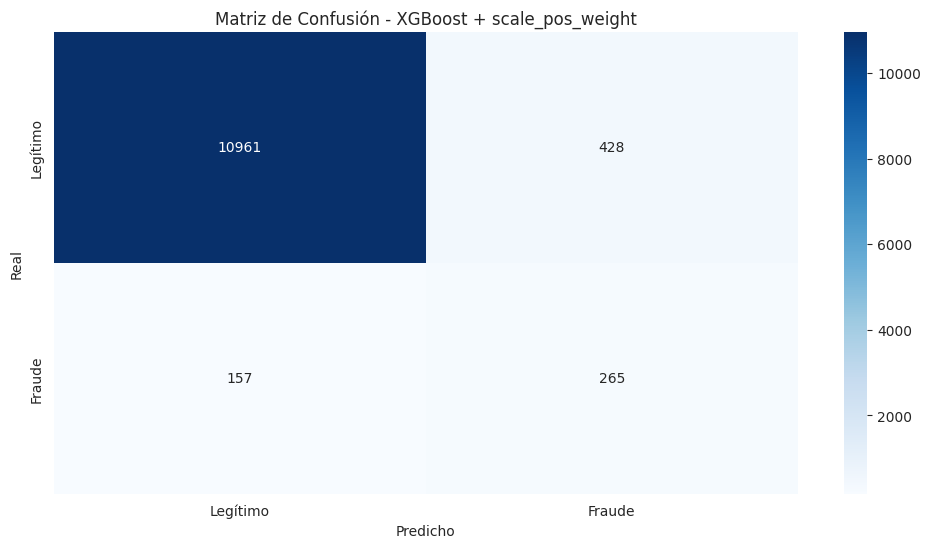

In [19]:
# Encontrar el mejor modelo basado en F2-score
mejor_fila = comparacion.loc[comparacion['F2-score'].idxmax()]
mejor_modelo = mejor_fila['Modelo']
print(f"El mejor modelo es: {mejor_modelo} con F2-score = {mejor_fila['F2-score']:.4f}")

# Seleccionar las predicciones correspondientes
if mejor_modelo == 'XGBoost + SMOTE':
    y_pred_mejor = y_pred_xgb_smote
elif mejor_modelo == 'XGBoost + scale_pos_weight':
    y_pred_mejor = y_pred_xgb_weighted
else:
    y_pred_mejor = y_pred_rf_smote

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legítimo', 'Fraude'], yticklabels=['Legítimo', 'Fraude'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión - {mejor_modelo}')
plt.show()

## 11. Conclusiones
---

- **XGBoost + scale_pos_weight** suele ser más rápido y evita el riesgo de sobreajuste a datos sintéticos.
- **SMOTE** puede ayudar cuando hay muy pocos ejemplos de fraude, pero requiere validación cuidadosa.
- **Random Forest + SMOTE** puede ser más lento y a veces menos potente que XGBoost.

En nuestro caso, el mejor modelo será el que tenga mayor F2-score (prioriza recall). Puedes ajustar hiperparámetros (GridSearchCV) para mejorar aún más.

Este pipeline completo demuestra:
- Manejo de datos desbalanceados
- Comparación de técnicas
- Evaluación con métricas realistas
